226147/226147 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


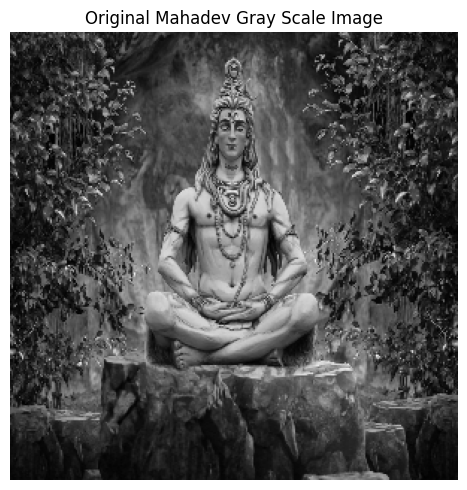

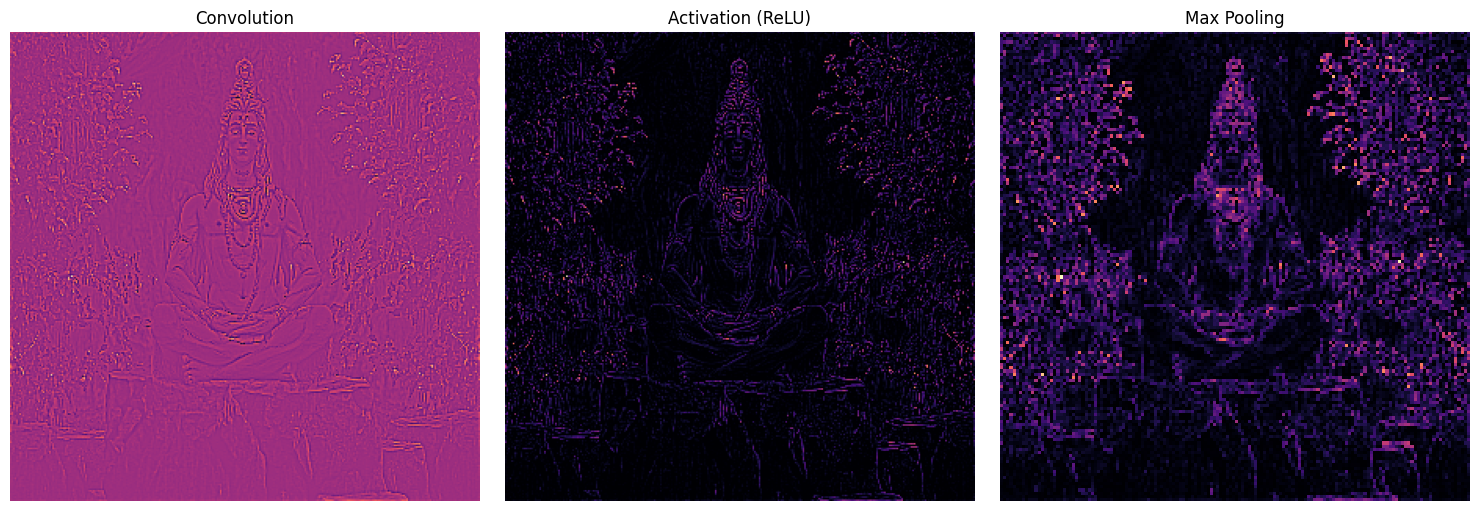

In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt

# Set the parameters
plt.rc('figure', autolayout=True)
plt.rc('image', cmap='magma')

# Define the kernel (Edge Detection)
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

# Image URL
image_url = "https://cdn.magicdecor.in/com/2023/10/27163547/Mahadev-3D-Wallpaper-for-Home-Wall.jpg"

#image
image_path = tf.keras.utils.get_file(
    fname="mahadev.jpg",
    origin=image_url,
    cache_dir="/tmp",
    cache_subdir=""
)
# Load image
image = tf.io.read_file(image_path)

# Decode image
image = tf.io.decode_jpeg(image, channels=1)

# Resize image
image = tf.image.resize(image, size=[300, 300])


# Display Original Image
img = tf.squeeze(image).numpy()

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Mahadev Gray Scale Image')
plt.show

# Reformat image for CNN
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)

# Reformat kernel
kernel = tf.reshape(kernel, [3,3,1,1])

# Convolution Layer
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1,1,1,1],
    padding='SAME'
)
# Activation Layer (ReLU)
image_detect = tf.nn.relu(image_filter)

# Pooling Layer
image_condense = tf.nn.max_pool2d(
    input=image_detect,
    ksize=2,
    strides=2,
    padding='SAME'
)
# Display Results
plt.figure(figsize=(15,5))

# Convolution Output
plt.subplot(1,3,1)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Convolution')

# Activation Output
plt.subplot(1,3,2)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title('Activation (ReLU)')

# Pooling Output
plt.subplot(1,3,3)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title('Max Pooling')
plt.show()
